<a href="https://colab.research.google.com/github/mugoyashariff/Towards-Explainable-and-Interpretable-Machine-Learning-in-Smart-Grids-in-Developing-Countries/blob/main/Latestmap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_1564/2860825188.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  data_colors_palette = plt.cm.get_cmap('tab20', len(countries_with_data))
/tmp/ipykernel_1564/2860825188.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  continent_colors_palette = plt.cm.get_cmap('Paired', len(continents_without_data))


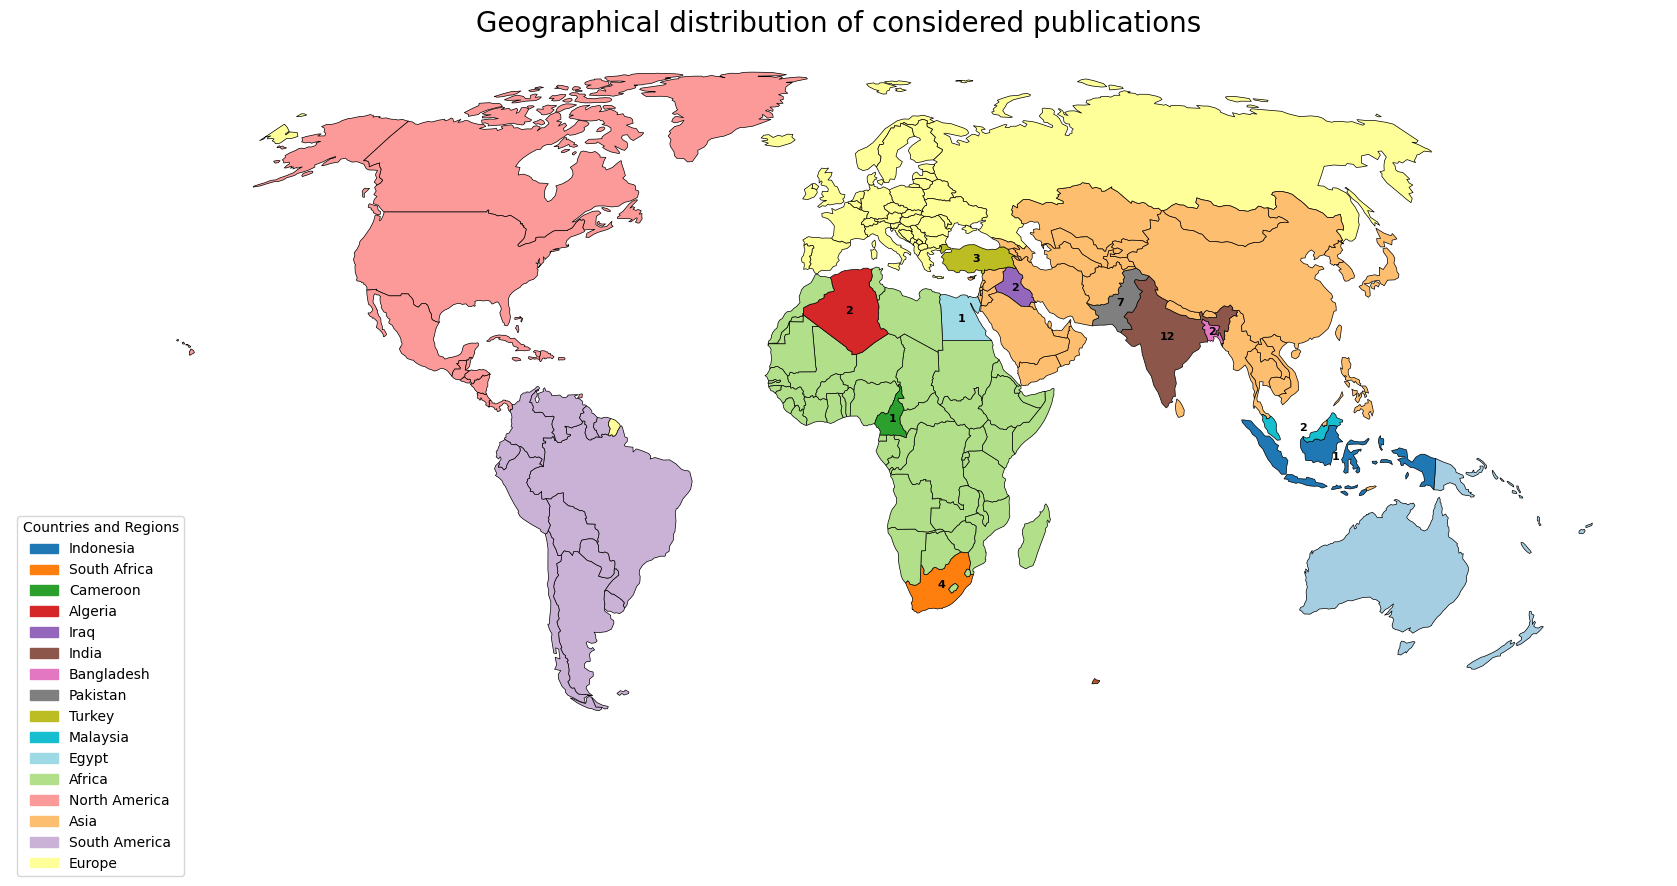

<Figure size 640x480 with 0 Axes>

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # For custom legend

import os
from google.colab import drive
drive.mount('/content/drive')
root_dir = "/content/drive/MyDrive/Colab Notebooks/Copy of Geographical Distribution of Publications.xlsx"
df_articles = pd.read_excel(root_dir)

# Prepare the counts DataFrame from df_articles
counts = df_articles.rename(columns={'Country': 'name', 'Number of Publications': 'count'})

# Load world map
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# --- 2. Reprojection & Optimization ---
# Reproject to a more "filled" projection (Robinson is great for maps)
world = world.to_crs("ESRI:54030")

# Merge counts with world map
world = world.merge(counts, how="left", left_on="NAME", right_on="name")

# Filter out Antarctica from the map
world = world[world['CONTINENT'] != 'Antarctica']

# --- 3. Prepare colors and plot ---

# Identify countries with data
world['has_data'] = world['count'].notna() & (world['count'] > 0)

# Get unique countries with data and unique continents without data
countries_with_data = world[world['has_data']]['NAME'].unique()
continents_without_data = world[~world['has_data']]['CONTINENT'].unique()

# Generate categorical colormaps
# For countries with data, use a distinct qualitative colormap (e.g., tab20)
# Ensure enough colors are available
if len(countries_with_data) > 0:
    # Using a list of colors directly for more control and distinctiveness
    # If more than 20 countries, colors will cycle from tab20
    data_colors_palette = plt.cm.get_cmap('tab20', len(countries_with_data))
    country_color_map = {country: data_colors_palette(i) for i, country in enumerate(countries_with_data)}
else:
    country_color_map = {}

# For continents without data, use another distinct qualitative colormap (e.g., Paired)
if len(continents_without_data) > 0:
    # If more than 12 continents, colors will cycle from Paired
    continent_colors_palette = plt.cm.get_cmap('Paired', len(continents_without_data))
    continent_color_map = {continent: continent_colors_palette(i) for i, continent in enumerate(continents_without_data)}
else:
    continent_color_map = {}

# Assign colors to each country based on whether it has data or its continent
world['plot_color'] = None # Initialize column

# Assign colors based on logic
for idx, row in world.iterrows():
    if row['has_data']:
        world.at[idx, 'plot_color'] = country_color_map.get(row['NAME'], 'grey') # Default to grey if not in map
    else:
        world.at[idx, 'plot_color'] = continent_color_map.get(row['CONTINENT'], 'lightgrey') # Default for no continent data


# --- 4. Plotting ---
# Use a wider aspect ratio (e.g., 20x10)
fig, ax = plt.subplots(1, 1, figsize=(20, 10))

# Plot the map using the 'plot_color' column
world.plot(color=world['plot_color'],
           ax=ax,
           edgecolor='black',
           linewidth=0.5)

# Annotate each country
for idx, row in world.iterrows():
    if pd.notna(row['count']) and row['count'] > 0:
        # Centroid is calculated in the new projection
        centroid = row['geometry'].centroid
        plt.annotate(text=int(row['count']),
                     xy=(centroid.x, centroid.y),
                     ha='center', va='center',
                     fontsize=8, color='black', fontweight='bold')

# --- 5. Custom Legend ---
legend_patches = []

# Legend for countries with data (removed count from label)
for country, color in country_color_map.items():
    legend_patches.append(mpatches.Patch(color=color, label=f'{country}'))

# Legend for continents without data
# Filter out continents that actually have data points, so we only label true "no data" continents
# Also filter out specific continents as requested
excluded_continents = ['Oceania', 'Antarctica', 'Seven seas (open ocean)']
for continent, color in continent_color_map.items():
    if continent not in excluded_continents:
        # Check if this continent has any countries that have no data
        if not world[(world['CONTINENT'] == continent) & (~world['has_data'])].empty:
            legend_patches.append(mpatches.Patch(color=color, label=f'{continent}')) # Removed (No Data)

# Add "Other (No Data)" for countries that ended up with lightgrey (neither data nor assigned continent color)
# Exclude if it's one of the continents that now have no data label.
if 'lightgrey' in world['plot_color'].values and not any(p.get_label() == 'Other' for p in legend_patches):
    legend_patches.append(mpatches.Patch(color='lightgrey', label='Other'))

# Place the legend outside the plot area at the bottom
ax.legend(handles=legend_patches, loc='lower left', fontsize=10, title="Countries and Regions", bbox_to_anchor=(0, -0.2))

# --- 6. Final Formatting ---
ax.set_title('Geographical distribution of considered publications', fontsize=20)
ax.set_axis_off()  # Removes the frame and ticks completely

# Adjust layout to remove extra whitespace and make space for legend
# Increase the bottom margin (e.g., from 0 to 0.2) to accommodate the legend
plt.tight_layout(rect=[0, 0.2, 1, 1])

plt.show()

# Save the map as a high-resolution PNG file
plt.savefig('geographical_distribution.png', dpi=300, bbox_inches='tight')